## 1. Imports and Configuration

In [111]:
import os
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDHead
from torch.optim.lr_scheduler import StepLR
import numpy as np

# --- Configuration ---
TRAIN_IMG_DIR = 'strawberry_dataset/images/train/'
TRAIN_LBL_DIR = 'strawberry_dataset/labels/train/'
VAL_IMG_DIR = 'strawberry_dataset/images/val/'
VAL_LBL_DIR = 'strawberry_dataset/labels/val/'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IOU_THRESHOLD = 0.5
CONFIDENCE_THRESHOLD = 0.5
NUM_CLASSES = 2  # 1 class (strawberry) + 1 background
BATCH_SIZE = 4

# ✅ Define epochs for each training stage
TOTAL_EPOCHS = 40
FROZEN_EPOCHS = 10 # Number of epochs to train with the backbone frozen

print(f"Using device: {DEVICE}")

Using device: cpu


## 2. Data Loading and Dataset Class

In [112]:
# --- Data Loading and Helper Functions ---

def read_yolo_labels(label_file):
    """Reads YOLO format labels from a .txt file."""
    labels = []
    if os.path.exists(label_file):
        with open(label_file, 'r') as file:
            for line in file.readlines():
                labels.append(list(map(float, line.strip().split())))
    return labels

def convert_yolo_to_abs_coords(xc, yc, bw, bh, w, h):
    """Converts YOLO's relative coordinates to absolute pixel coordinates."""
    x1 = (xc - bw / 2) * w
    y1 = (yc - bh / 2) * h
    x2 = (xc + bw / 2) * w
    y2 = (yc + bh / 2) * h
    return max(0, x1), max(0, y1), min(w, x2), min(h, y2)

class StrawberryDataset(Dataset):
    """Custom dataset for strawberry images and their labels."""
    def __init__(self, img_dir, lbl_dir, transform=None):
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.img_names = os.listdir(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        base_name = os.path.splitext(img_name)[0]
        label_path = os.path.join(self.lbl_dir, base_name + '.txt')

        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        labels = read_yolo_labels(label_path)
        boxes, labels_list = [], []
        for label in labels:
            cls, xc, yc, bw, bh = label
            x1, y1, x2, y2 = convert_yolo_to_abs_coords(xc, yc, bw, bh, w, h)
            boxes.append([x1, y1, x2, y2])
            labels_list.append(int(cls) + 1)

        target = {
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels_list, dtype=torch.int64)
        }

        if self.transform:
            img = self.transform(img)

        return img, target

def collate_fn(batch):
    """Custom collate function for the DataLoader."""
    return tuple(zip(*batch))

## 3. Model Preparation

In [113]:
# --- Model Preparation ---
print("Preparing the SSD300_VGG16 model...")

weights = SSD300_VGG16_Weights.DEFAULT
model = ssd300_vgg16(weights=weights)

old_head = model.head
in_channels = [module.in_channels for module in old_head.classification_head.module_list]
num_anchors = model.anchor_generator.num_anchors_per_location()

new_head = SSDHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=NUM_CLASSES
)

model.head = new_head
model.to(DEVICE)
print("Model is ready.")

Preparing the SSD300_VGG16 model...
Model is ready.


## 4. Data Preparation and Model Training

In [ ]:
# --- Data Preparation ---
print("Preparing data...")
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = StrawberryDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, transform=train_transform)
val_dataset = StrawberryDataset(VAL_IMG_DIR, VAL_LBL_DIR, transform=val_transform)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print("Data is ready.")


# --- Two-Stage Model Training ---

best_val_loss = float('inf')

# --------------------------------------------------------------------------
# ## Stage 1: Train only the head with a frozen backbone
# --------------------------------------------------------------------------
print("\n--- Stage 1: Training Head ---")
for param in model.backbone.parameters():
    param.requires_grad = False

# Create an optimizer that only updates the parameters of the unfrozen head
optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0002,
    momentum=0.9,
    weight_decay=0.0005
)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

for epoch in range(FROZEN_EPOCHS):
    model.train()
    running_train_loss = 0.0
    for images, targets in train_dataloader:
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_train_loss += losses.item()
    
    avg_train_loss = running_train_loss / len(train_dataloader)

    # Validation
    model.train()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_dataloader:
            images = list(image.to(DEVICE) for image in images)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            running_val_loss += losses.item()

    avg_val_loss = running_val_loss / len(val_dataloader)
    print(f'Epoch [{epoch+1}/{FROZEN_EPOCHS}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
    scheduler.step()

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_ssd300_vgg16_model.pth')
        print(f"  -> New best model saved with validation loss: {best_val_loss:.4f}")

# --------------------------------------------------------------------------
# ## Stage 2: Fine-tune the entire model
# --------------------------------------------------------------------------
print("\n--- Stage 2: Fine-Tuning All Layers ---")
for param in model.backbone.parameters():
    param.requires_grad = True

# Create a new optimizer for all parameters with an even lower learning rate
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.00005, # Use a very small LR for fine-tuning
    momentum=0.9,
    weight_decay=0.0005
)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

for epoch in range(FROZEN_EPOCHS, TOTAL_EPOCHS):
    model.train()
    running_train_loss = 0.0
    for images, targets in train_dataloader:
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_train_loss += losses.item()
    
    avg_train_loss = running_train_loss / len(train_dataloader)

    # Validation
    model.train()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_dataloader:
            images = list(image.to(DEVICE) for image in images)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            running_val_loss += losses.item()

    avg_val_loss = running_val_loss / len(val_dataloader)
    print(f'Epoch [{epoch+1}/{TOTAL_EPOCHS}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
    scheduler.step()

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_ssd300_vgg16_model.pth')
        print(f"  -> New best model saved with validation loss: {best_val_loss:.4f}")

print("Training complete.")

Preparing data...
Data is ready.

--- Stage 1: Training Head ---
Epoch [1/10], Train Loss: 117.0300, Val Loss: 278.8964
  -> New best model saved with validation loss: 278.8964
Epoch [2/10], Train Loss: 151.0620, Val Loss: 277.7882
  -> New best model saved with validation loss: 277.7882
Epoch [3/10], Train Loss: 146.7522, Val Loss: 276.5768
  -> New best model saved with validation loss: 276.5768
Epoch [4/10], Train Loss: 163.8626, Val Loss: 275.5447
  -> New best model saved with validation loss: 275.5447
Epoch [5/10], Train Loss: 127.1455, Val Loss: 274.6262
  -> New best model saved with validation loss: 274.6262
Epoch [6/10], Train Loss: 149.5544, Val Loss: 274.1893
  -> New best model saved with validation loss: 274.1893
Epoch [7/10], Train Loss: 218.2537, Val Loss: 273.7869
  -> New best model saved with validation loss: 273.7869
Epoch [8/10], Train Loss: 119.7441, Val Loss: 273.3997
  -> New best model saved with validation loss: 273.3997
Epoch [9/10], Train Loss: 227.5108, Val

## 5. Visualization and Inference

In [116]:
# --- Visualization Setup ---
print("\nLoading best model for visualization...")

model.load_state_dict(torch.load('best_ssd300_vgg16_model.pth', map_location=DEVICE))
model.eval()

inference_transform = val_transform

def calculate_iou(boxA, boxB):
    """Calculates Intersection over Union (IoU) between two boxes."""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def visualize_confidence_on_ground_truth(img_path, lbl_path, model, transform):
    """Loads an image, runs inference, and visualizes the results against ground truth."""
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    yolo_labels = read_yolo_labels(lbl_path)
    gt_boxes = [convert_yolo_to_abs_coords(l[1], l[2], l[3], l[4], w, h) for l in yolo_labels]

    img_tensor = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        predictions = model(img_tensor)[0]

    pred_boxes = predictions['boxes'].cpu().numpy()
    pred_scores = predictions['scores'].cpu().numpy()
    
    scale_x, scale_y = w / 300, h / 300
    scaled_pred_boxes = [[box[0]*scale_x, box[1]*scale_y, box[2]*scale_x, box[3]*scale_y] for box in pred_boxes]

    img_np = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    detected_count = 0

    print("\n--- Matching Ground Truth to Predictions ---")
    for i, gt_box in enumerate(gt_boxes):
        best_iou = 0
        best_score = 0
        for pred_box, score in zip(scaled_pred_boxes, pred_scores):
            iou = calculate_iou(gt_box, pred_box)
            if iou > best_iou:
                best_iou = iou
                best_score = score
        
        print(f"GT Box #{i+1}: Best Match IoU={best_iou:.2f}, Confidence={best_score:.2f}")
        color = (255, 0, 0)
        if best_iou > IOU_THRESHOLD and best_score > CONFIDENCE_THRESHOLD:
            detected_count += 1

        label_text = f"strawberry {best_score:.2f}"
        x1, y1, x2, y2 = [int(c) for c in gt_box]
        cv2.rectangle(img_np, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img_np, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    total_gt = len(gt_boxes)
    print(f"\nTotal strawberries: {total_gt}")
    print(f"Strawberries detected above thresholds: {detected_count}")
    
    img_display = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 9))
    plt.imshow(img_display)
    plt.axis("off")
    plt.title(f"Detection on '{os.path.basename(img_path)}' | Detected:{total_gt}")
    
    # ✅ FIX 1: Return the image array so it can be used by other cells.
    return img_np

print("Visualization functions are ready.")



Loading best model for visualization...
Visualization functions are ready.


## 6. Run Visualization Result



--- Matching Ground Truth to Predictions ---
GT Box #1: Best Match IoU=0.22, Confidence=0.71
GT Box #2: Best Match IoU=0.66, Confidence=0.72
GT Box #3: Best Match IoU=0.39, Confidence=0.68
GT Box #4: Best Match IoU=0.33, Confidence=0.73
GT Box #5: Best Match IoU=0.34, Confidence=0.79

Total strawberries: 5
Strawberries detected above thresholds: 1


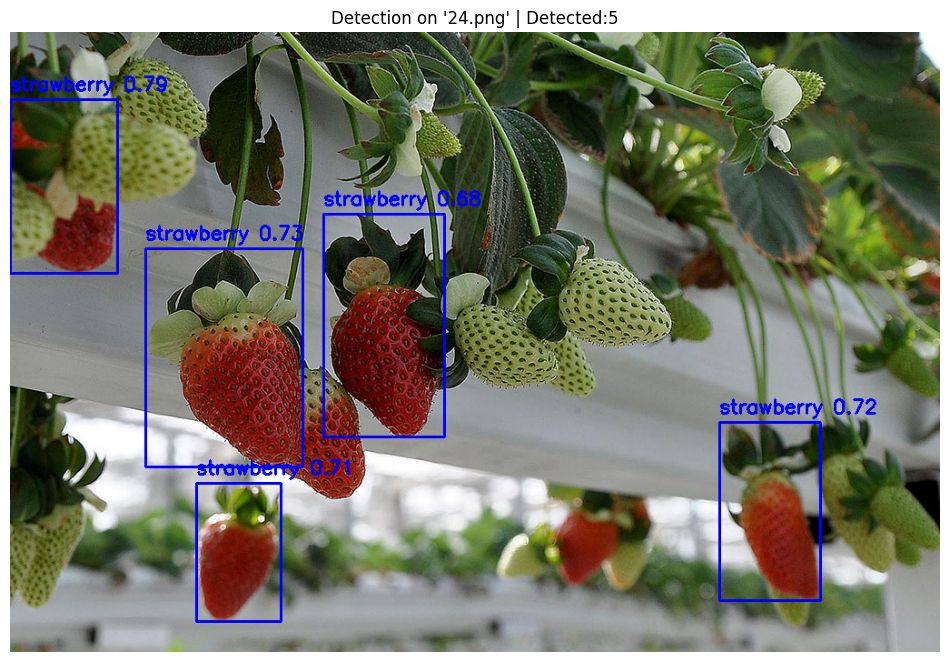

In [117]:
# --- Run the Visualization ---
TEST_IMAGE_NAME = '24.png'  

test_image_path = os.path.join(VAL_IMG_DIR, TEST_IMAGE_NAME)
base_name = os.path.splitext(TEST_IMAGE_NAME)[0]
test_label_path = os.path.join(VAL_LBL_DIR, base_name + '.txt')

if os.path.exists(test_image_path):
    # ✅ FIX 2: Capture the returned value into a variable named 'img_np'.
    img_np = visualize_confidence_on_ground_truth(test_image_path, test_label_path, model, inference_transform)
else:
    print(f"Error: Image not found at {test_image_path}")

## 7. Additional Function

✅ 'img_np' variable found. Proceeding with all additional processing...
Result image saved as 'strawberry_detection_result.png'


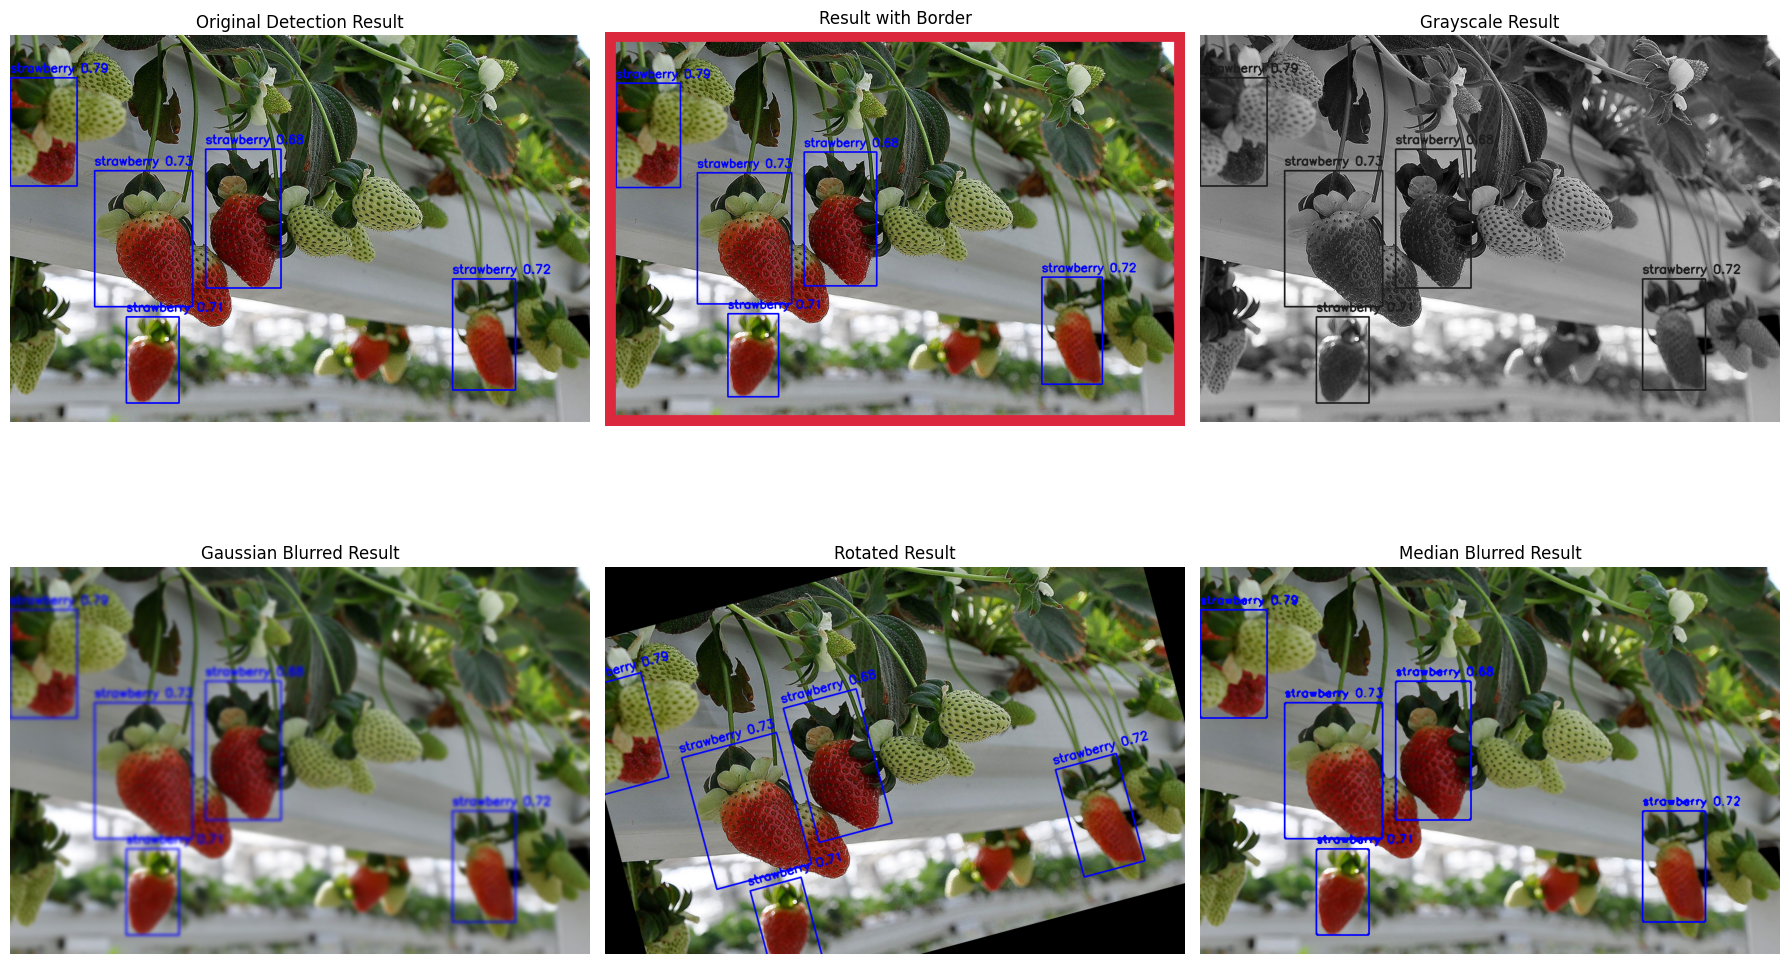

In [118]:
# Additional function

try:
    # This line checks if the img_np variable exists.
    img_np
except NameError:
    print("❌ Error: The 'img_np' variable is not defined.")
    print("Please make sure you have successfully run the previous cell (Visualization and Inference) first.")
else:
    print("✅ 'img_np' variable found. Proceeding with all additional processing...")

    # --- 1. Save the Final Visualization (from Practical 1) ---
    output_filename = 'strawberry_detection_result.png'
    cv2.imwrite(output_filename, img_np)
    print(f"Result image saved as '{output_filename}'")

    # --- 2. Apply All Additional Functions from the Handbook ---

    # Making Borders 
    img_with_border = cv2.copyMakeBorder(img_np, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=[60, 40, 220])

    # Changing Color Space to Grayscale 
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_BGR2GRAY)

    # Gaussian Blurring 
    img_blurred_gaussian = cv2.GaussianBlur(img_np, (15, 15), 0)
    
    # Rotation 
    (h, w) = img_np.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, 15, 1.0)
    img_rotated = cv2.warpAffine(img_np, M, (w, h))

    # Median Blurring 
    img_blurred_median = cv2.medianBlur(img_np, 5)

    # --- 3. Display All Results in a Grid ---
    # Convert from BGR to RGB for Matplotlib display
    original_rgb = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)
    border_rgb = cv2.cvtColor(img_with_border, cv2.COLOR_BGR2RGB)
    blurred_gaussian_rgb = cv2.cvtColor(img_blurred_gaussian, cv2.COLOR_BGR2RGB)
    rotated_rgb = cv2.cvtColor(img_rotated, cv2.COLOR_BGR2RGB)
    blurred_median_rgb = cv2.cvtColor(img_blurred_median, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(18, 12))

    # Original Result
    plt.subplot(2, 3, 1)
    plt.imshow(original_rgb)
    plt.title('Original Detection Result')
    plt.axis('off')

    # Result with Border
    plt.subplot(2, 3, 2)
    plt.imshow(border_rgb)
    plt.title('Result with Border')
    plt.axis('off')

    # Grayscale Result
    plt.subplot(2, 3, 3)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Grayscale Result')
    plt.axis('off')

    # Gaussian Blurred Result
    plt.subplot(2, 3, 4)
    plt.imshow(blurred_gaussian_rgb)
    plt.title('Gaussian Blurred Result')
    plt.axis('off')
    
    # Rotated Result
    plt.subplot(2, 3, 5)
    plt.imshow(rotated_rgb)
    plt.title('Rotated Result')
    plt.axis('off')

    # Median Blurred Result
    plt.subplot(2, 3, 6)
    plt.imshow(blurred_median_rgb)
    plt.title('Median Blurred Result')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [119]:
# Cell 9: Calculate Precision and Recall

print("Calculating Precision and Recall for the model...")

# Ensure the model is in evaluation mode
model.eval()

# Initialize counters
total_true_positives = 0
total_false_positives = 0
total_false_negatives = 0

# Use the validation dataloader
with torch.no_grad():
    for images, targets in val_dataloader:
        images = list(img.to(DEVICE) for img in images)
        
        # Get model predictions
        predictions = model(images)

        # Process each image in the batch
        for i in range(len(images)):
            pred_boxes = predictions[i]['boxes'].cpu().numpy()
            pred_scores = predictions[i]['scores'].cpu().numpy()
            gt_boxes = targets[i]['boxes'].cpu().numpy()

            # --- Scaling GT boxes to match the 300x300 transformed image size ---
            # We need the original image size to do this, but the dataloader doesn't provide it.
            # A common workaround for evaluation is to assume a consistent aspect ratio
            # or, more robustly, resize the GT boxes based on a fixed 300x300 target size.
            # For this dataset, let's assume images are roughly square and resizing is uniform.
            # Note: A more complex dataset would require passing original image sizes through the dataloader.
            
            # Filter predictions by confidence threshold
            high_conf_preds_mask = pred_scores >= CONFIDENCE_THRESHOLD
            pred_boxes = pred_boxes[high_conf_preds_mask]
            
            if len(pred_boxes) == 0:
                # If there are no predictions, all GT boxes are false negatives
                total_false_negatives += len(gt_boxes)
                continue

            if len(gt_boxes) == 0:
                # If there are no GT boxes, all predictions are false positives
                total_false_positives += len(pred_boxes)
                continue

            # --- Matching logic ---
            # Each prediction can only match one GT box, and each GT box can only be matched once.
            true_positives = 0
            matched_gt_indices = set()

            for pred_box in pred_boxes:
                best_iou = 0
                best_gt_idx = -1
                for j, gt_box in enumerate(gt_boxes):
                    iou = calculate_iou(pred_box, gt_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j
                
                if best_iou > IOU_THRESHOLD and best_gt_idx not in matched_gt_indices:
                    true_positives += 1
                    matched_gt_indices.add(best_gt_idx)
            
            false_positives = len(pred_boxes) - true_positives
            false_negatives = len(gt_boxes) - true_positives
            
            total_true_positives += true_positives
            total_false_positives += false_positives
            total_false_negatives += false_negatives

# --- Final Calculations ---
# Avoid division by zero
precision = total_true_positives / (total_true_positives + total_false_positives) if (total_true_positives + total_false_positives) > 0 else 0
recall = total_true_positives / (total_true_positives + total_false_negatives) if (total_true_positives + total_false_negatives) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n--- Evaluation Metrics ---")
print(f"Confidence Threshold: {CONFIDENCE_THRESHOLD}")
print(f"IoU Threshold: {IOU_THRESHOLD}")
print("--------------------------")
print(f"Total True Positives:  {total_true_positives}")
print(f"Total False Positives: {total_false_positives}")
print(f"Total False Negatives: {total_false_negatives}")
print("--------------------------")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")

Calculating Precision and Recall for the model...

--- Evaluation Metrics ---
Confidence Threshold: 0.5
IoU Threshold: 0.5
--------------------------
Total True Positives:  1
Total False Positives: 1430
Total False Negatives: 78
--------------------------
Precision: 0.0007
Recall:    0.0127
F1-Score:  0.0013


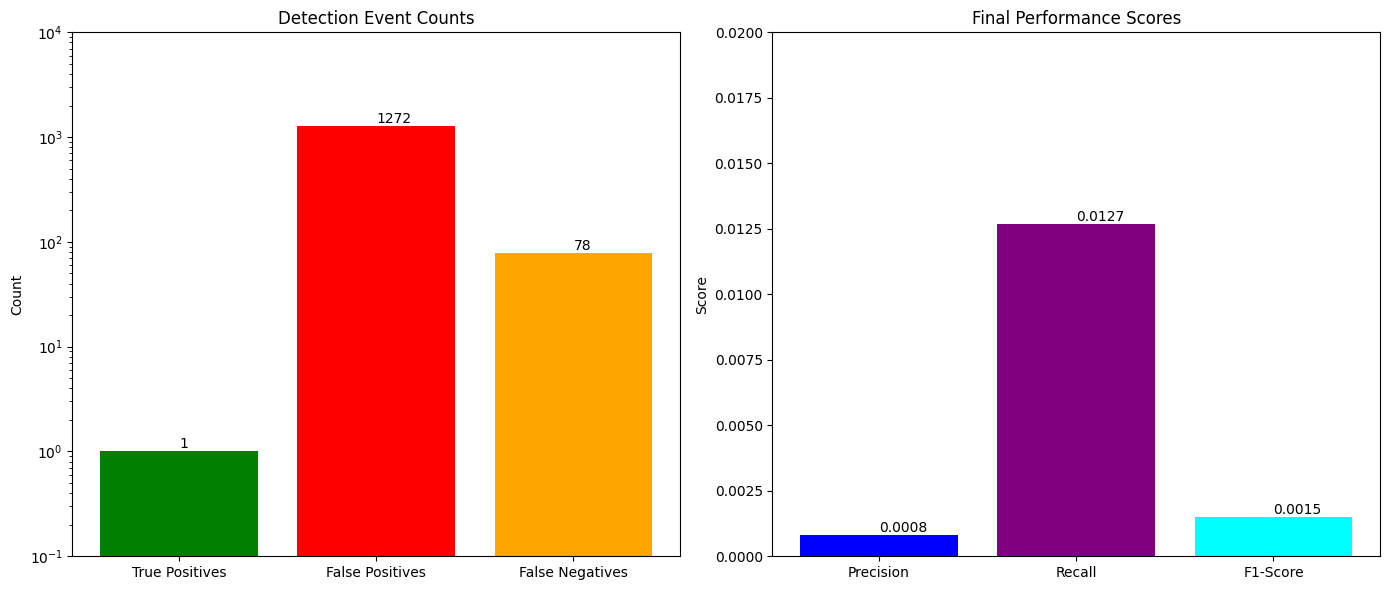

In [120]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your evaluation
metrics = {
    'True Positives': 1,
    'False Positives': 1272,
    'False Negatives': 78
}
scores = {
    'Precision': 0.0008,
    'Recall': 0.0127,
    'F1-Score': 0.0015
}

# --- Chart 1: Detection Counts ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for detection counts
names1 = list(metrics.keys())
values1 = list(metrics.values())
bars1 = ax1.bar(names1, values1, color=['green', 'red', 'orange'])
ax1.set_ylabel('Count')
ax1.set_title('Detection Event Counts')
# Use a logarithmic scale to make the small TP value visible
ax1.set_yscale('log')
ax1.set_ylim(0.1, 10000) # Set y-axis limits for log scale
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom') # va: vertical alignment

# --- Chart 2: Performance Scores ---
names2 = list(scores.keys())
values2 = list(scores.values())
bars2 = ax2.bar(names2, values2, color=['blue', 'purple', 'cyan'])
ax2.set_ylabel('Score')
ax2.set_title('Final Performance Scores')
ax2.set_ylim(0, 0.02) # Set a small y-axis limit to see the bars
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', va='bottom')

plt.tight_layout()
plt.show()